#**Assignment 05: Artificial Neural Networks**

In [239]:
#import libraries

In [240]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

%pip install keras-tuner
import keras_tuner as kt

import warnings
warnings.filterwarnings('ignore')

In [241]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [242]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [243]:
df= pd.read_csv('/content/mobile_price_classification.csv')
df.head()

,battery_power,bluetooth,clock_speed,dual_sim,front_cam,4G,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [244]:
df.duplicated().sum()

np.int64(0)

In [245]:
df.isna().sum()

,0
battery_power,0
bluetooth,0
clock_speed,0
dual_sim,0
front_cam,0
4G,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


In [246]:
df.shape

(2000, 21)

In [247]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   battery_power   2000 non-null   int64  
 1   bluetooth       2000 non-null   int64  
 2   clock_speed     2000 non-null   float64
 3   dual_sim        2000 non-null   int64  
 4   front_cam       2000 non-null   int64  
 5   4G              2000 non-null   int64  
 6   int_memory      2000 non-null   int64  
 7   m_dep           2000 non-null   float64
 8   mobile_wt       2000 non-null   int64  
 9   n_cores         2000 non-null   int64  
 10  primary_camera  2000 non-null   int64  
 11  px_height       2000 non-null   int64  
 12  px_width        2000 non-null   int64  
 13  ram             2000 non-null   int64  
 14  sc_h            2000 non-null   int64  
 15  sc_w            2000 non-null   int64  
 16  talk_time       2000 non-null   int64  
 17  three_g         2000 non-null   i

In [248]:
df.describe()

,battery_power,bluetooth,clock_speed,dual_sim,front_cam,4G,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [249]:
df['price_range'].value_counts()

,count
price_range,
1,500
2,500
3,500
0,500


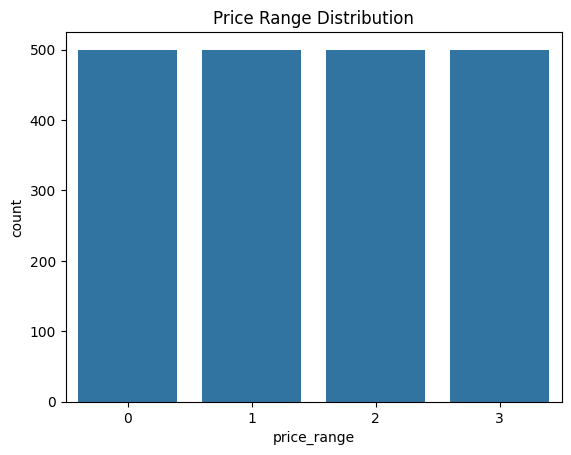

In [250]:
sns.countplot(x='price_range', data=df)
plt.title("Price Range Distribution")
plt.show()

0.03189847179278164


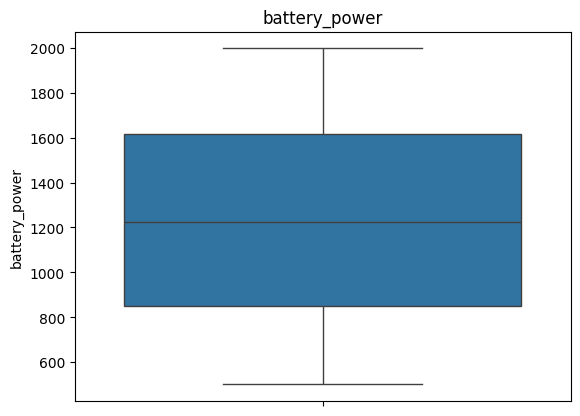

0.020016015215014945


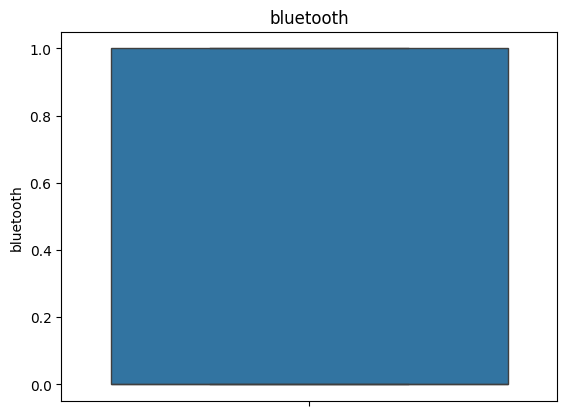

0.1780841202790887


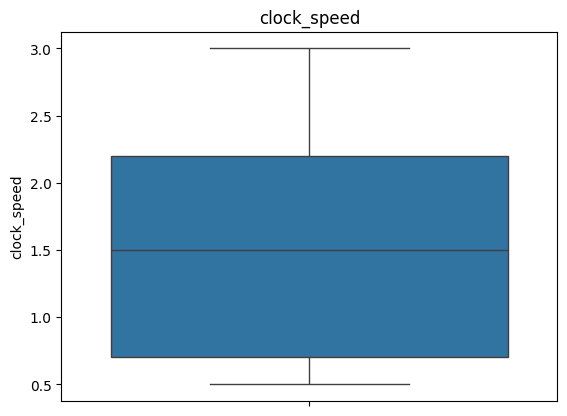

-0.03803539334775485


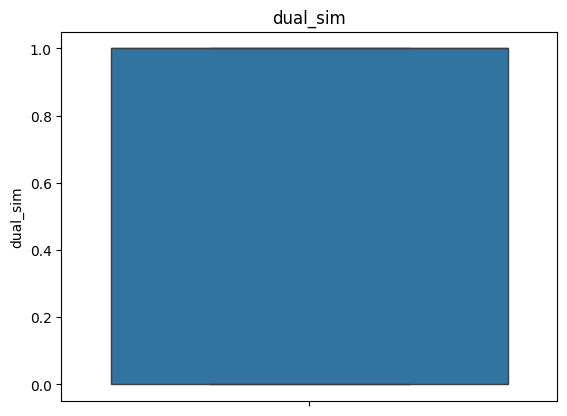

1.0198114105315519


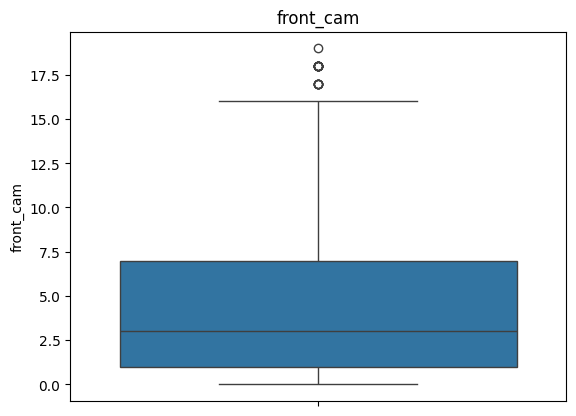

-0.08614423907054716


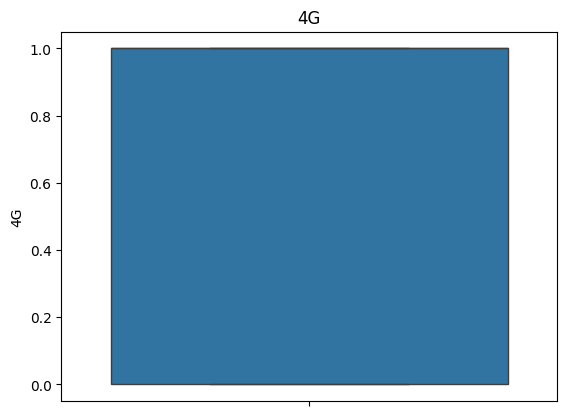

0.05788932785206039


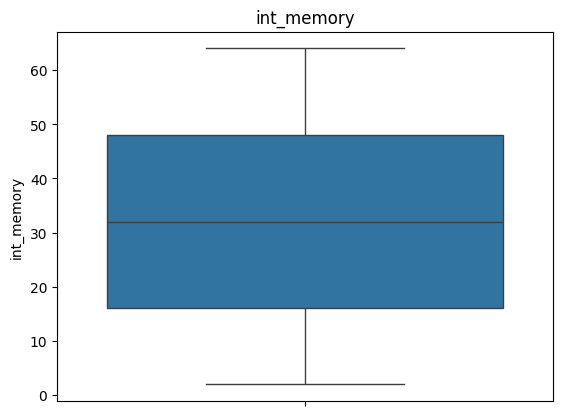

0.08908200979245855


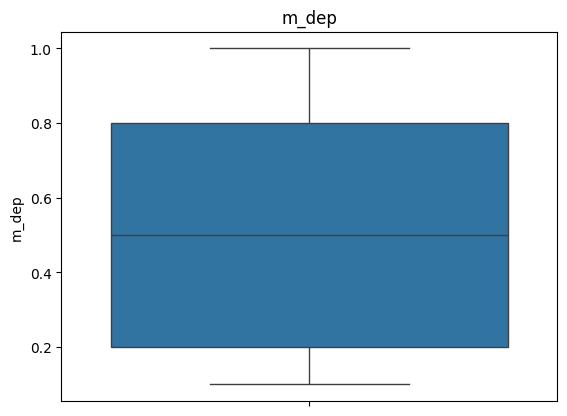

0.006558157428692449


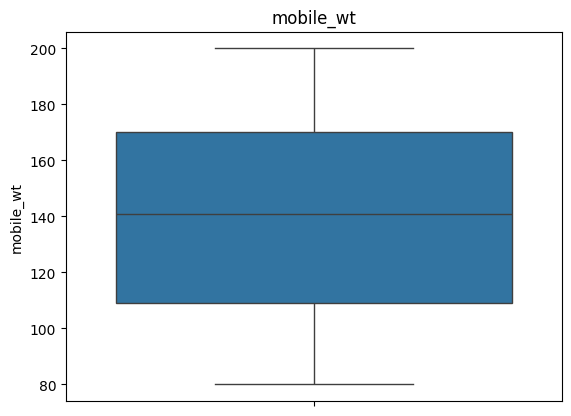

0.0036275083137803994


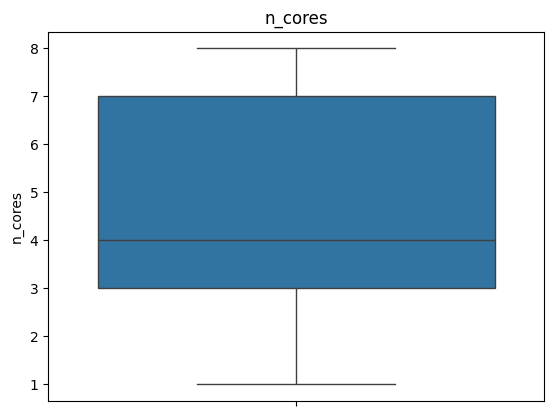

0.017306150471392553


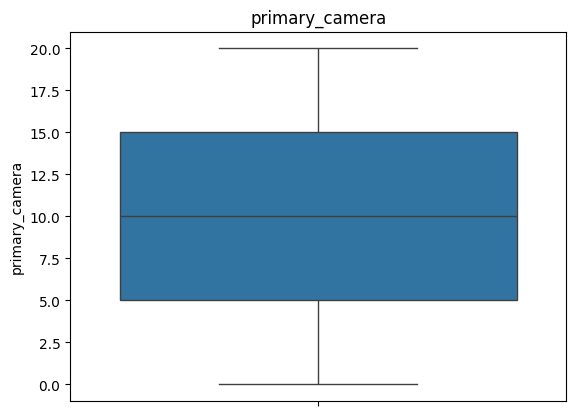

0.6662712560691598


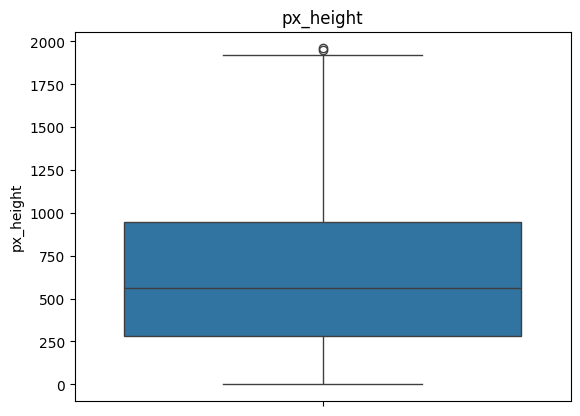

0.014787473768006081


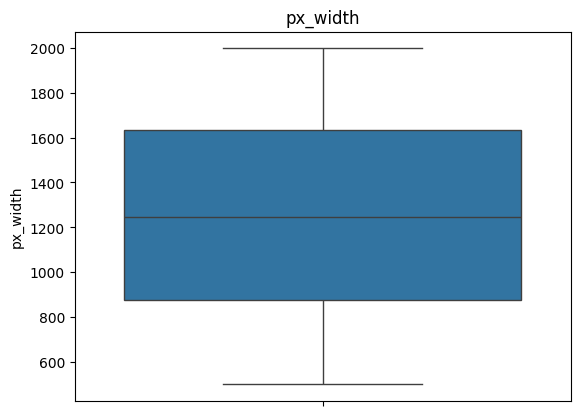

0.006628035398750348


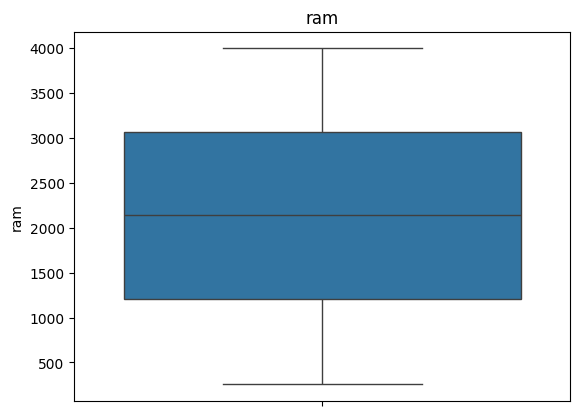

-0.09888424098283438


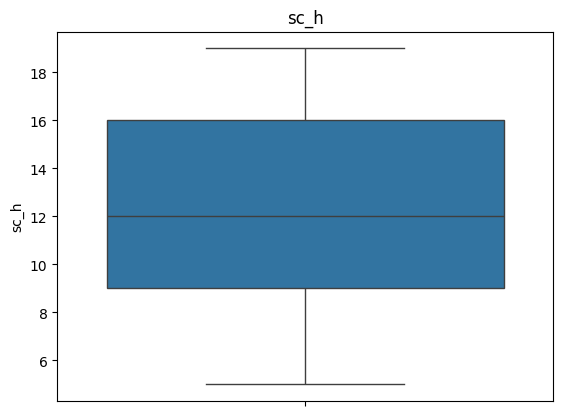

0.6337870734456067


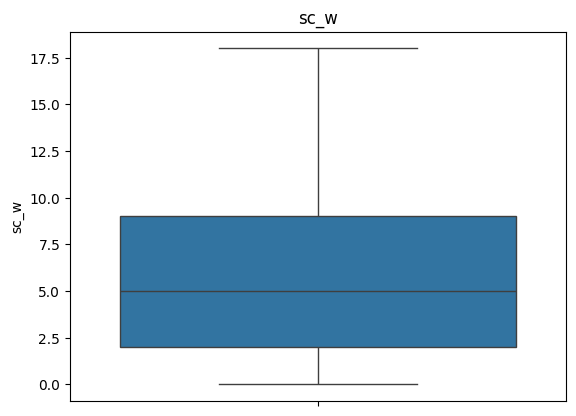

0.009511762221541457


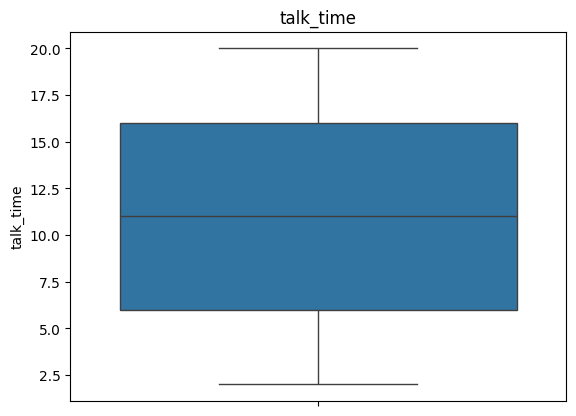

-1.2281416344153246


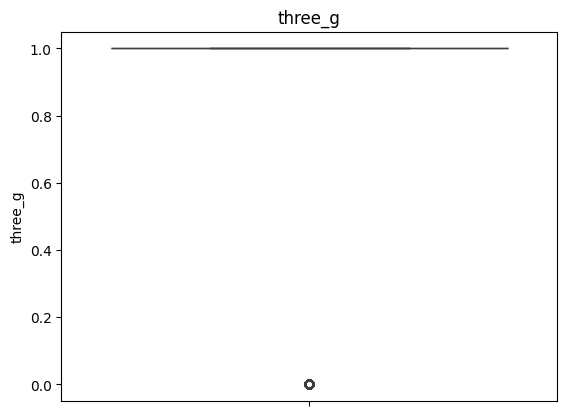

-0.012009224801531652


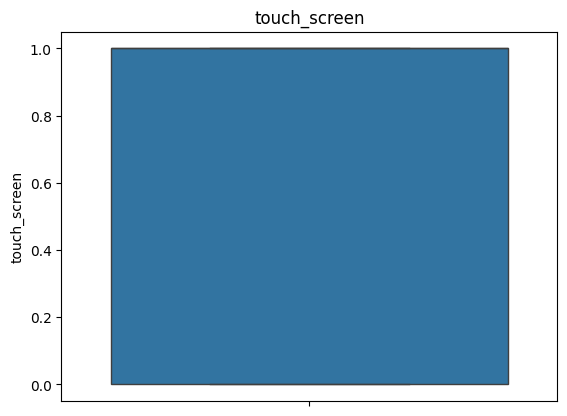

-0.028023766608637157


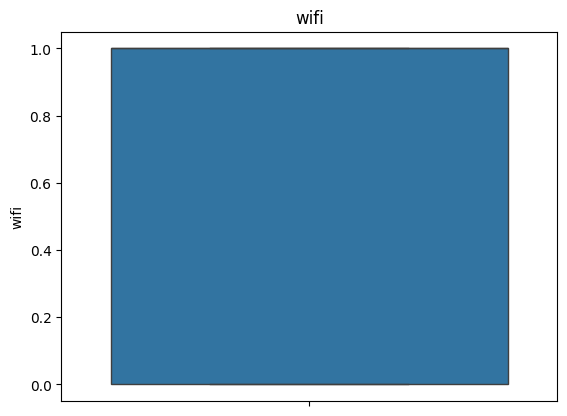

0.0


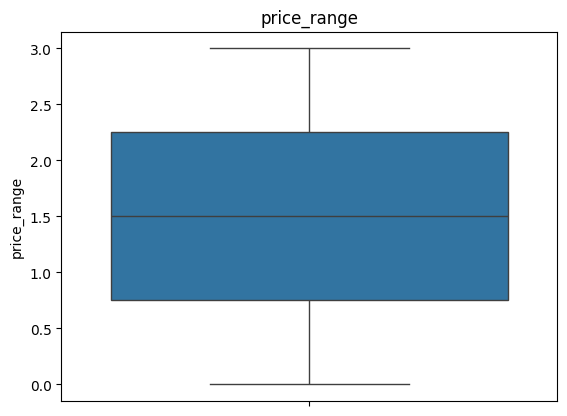

In [251]:
for i in df.columns:
 sns.boxplot(df[i])
 print(df[i].skew())
 plt.title(i)
 plt.show()

In [252]:
df['sc_h'].value_counts()

,count
sc_h,
17,193
12,157
7,151
16,143
14,143
15,135
13,131
11,126
10,125


In [253]:
df

,battery_power,bluetooth,clock_speed,dual_sim,front_cam,4G,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [254]:
#scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scale_col=['battery_power','int_memory','mobile_wt','px_height','px_width','ram',]
df[scale_col]= scaler.fit_transform(df[scale_col])


In [255]:
df

,battery_power,bluetooth,clock_speed,dual_sim,front_cam,4G,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,-0.902597,0,2.2,0,1,0,-1.380644,0.6,1.349249,2,...,-1.408949,-1.146784,0.391703,9,7,19,0,0,1,1
1,-0.495139,1,0.5,1,0,1,1.155024,0.7,-0.120059,3,...,0.585778,1.704465,0.467317,17,3,7,1,1,0,2
2,-1.537686,1,0.5,1,2,1,0.493546,0.9,0.134244,5,...,1.392684,1.074968,0.441498,11,2,9,1,1,0,2
3,-1.419319,1,2.5,0,0,0,-1.215274,0.8,-0.261339,6,...,1.286750,1.236971,0.594569,16,8,11,1,0,0,2
4,1.325906,1,1.2,0,13,1,0.658915,0.6,0.021220,2,...,1.268718,-0.091452,-0.657666,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,-1.011860,1,0.5,1,0,1,-1.656260,0.8,-0.967737,6,...,1.300273,1.477661,-1.342799,13,4,19,1,1,0,0
1996,1.653694,1,2.6,1,0,0,0.383299,0.2,1.320993,4,...,0.608317,1.651235,-0.085031,11,10,16,1,1,1,2
1997,1.530773,0,0.9,1,1,1,0.217930,0.7,-0.911225,8,...,0.502383,0.880565,0.860139,9,1,5,1,1,0,3
1998,0.622527,0,0.9,0,4,1,0.769162,0.1,0.134244,5,...,-0.696707,-1.345816,-1.157454,18,10,19,1,1,1,0


In [256]:
X = df.drop('price_range', axis=1)
y = df['price_range']

In [257]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [258]:
#Build ANN Model

model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dense(64, activation='relu'))

model.add(Dense(32, activation='relu'))

model.add(Dense(4, activation='softmax'))

In [259]:
#Compile Model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [260]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [261]:
#train model

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3516 - loss: 1.3473 - val_accuracy: 0.4563 - val_loss: 1.2567
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5383 - loss: 1.0775 - val_accuracy: 0.5656 - val_loss: 0.9624
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6789 - loss: 0.8094 - val_accuracy: 0.7312 - val_loss: 0.6972
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7758 - loss: 0.5961 - val_accuracy: 0.7563 - val_loss: 0.5670
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8375 - loss: 0.4597 - val_accuracy: 0.8562 - val_loss: 0.4066
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8562 - loss: 0.3820 - val_accuracy: 0.8406 - val_loss: 0.3912
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8727 - loss: 0.3300 - val_accuracy: 0.8781 - val_loss: 0.3153
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8883 - loss: 0.2978 - val_accuracy: 0.843

In [262]:
#Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9350 - loss: 0.1569  
Test Accuracy: 0.9350000023841858


In [263]:
# Prediction

y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [264]:
#Accuracy
accuracy_score(y_test, y_pred)

0.935

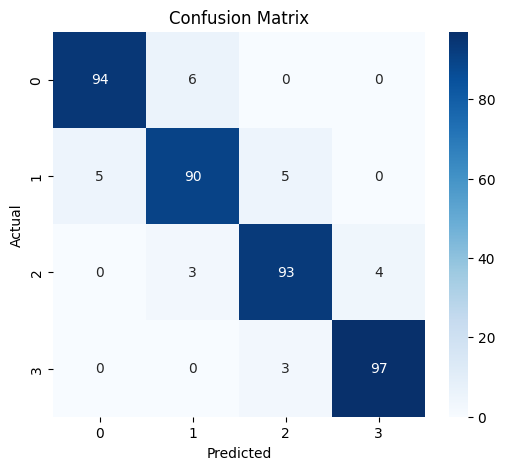

In [265]:
#Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [266]:
#Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94       100
           1       0.91      0.90      0.90       100
           2       0.92      0.93      0.93       100
           3       0.96      0.97      0.97       100

    accuracy                           0.94       400
   macro avg       0.93      0.94      0.93       400
weighted avg       0.93      0.94      0.93       400



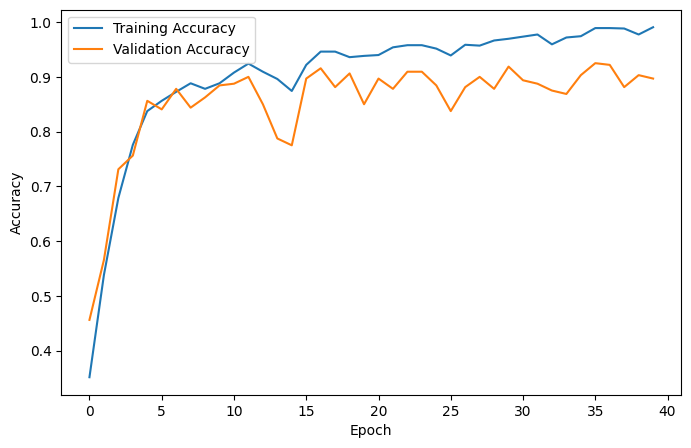

In [267]:
# Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

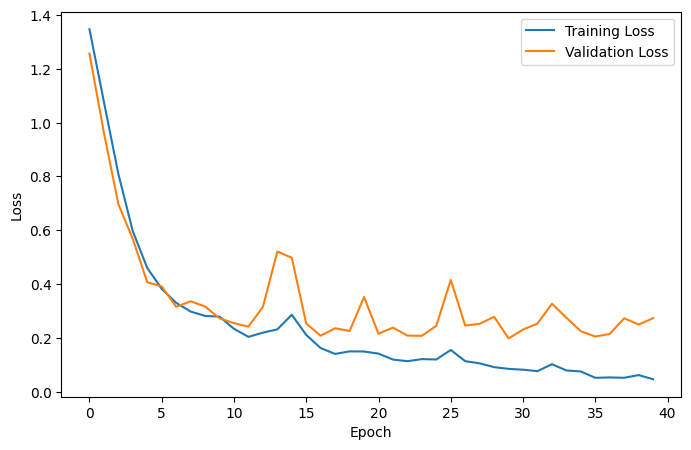

In [268]:
#Loss Graph
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [269]:
#Hyperparameter Tuning
def build_model(hp):

    model = Sequential()

    units1 = hp.Int("units1", min_value=32, max_value=256, step=32)

    units2 = hp.Int("units2", min_value=16, max_value=128, step=16)

    model.add(Dense(units1,
                    activation='relu',
                    input_shape=(X_train.shape[1],)))

    model.add(Dense(units2,
                    activation='relu'))

    model.add(Dense(4,
                    activation='softmax'))

    learning_rate = hp.Choice(
        'learning_rate',
        values=[0.01,0.001,0.0001]
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [270]:
#Create Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    overwrite=True,
    directory='ANN_Tuning',
    project_name='MobilePrice'
)

In [271]:
tuner.search(
    X_train,
    y_train,
    epochs=30,
    validation_split=0.2,
    verbose=1
)

Trial 10 Complete [00h 00m 11s]
val_accuracy: 0.84375

Best val_accuracy So Far: 0.925000011920929
Total elapsed time: 00h 01m 28s


In [272]:
best_hp = tuner.get_best_hyperparameters()[0]

print(best_hp.values)

{'units1': 128, 'units2': 96, 'learning_rate': 0.01}


In [273]:
best_model = tuner.get_best_models()[0]

In [274]:
best_model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9297 - loss: 0.1765 - val_accuracy: 0.8750 - val_loss: 0.3090
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9656 - loss: 0.0897 - val_accuracy: 0.9250 - val_loss: 0.1993
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9570 - loss: 0.1049 - val_accuracy: 0.8719 - val_loss: 0.3412
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9547 - loss: 0.1073 - val_accuracy: 0.8938 - val_loss: 0.2980
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9648 - loss: 0.0931 - val_accuracy: 0.9094 - val_loss: 0.2634
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9461 - loss: 0.1410 - val_accuracy: 0.8875 - val_loss: 0.3637
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9516 - loss: 0.1248 - val_accuracy: 0.9125 - val_loss: 0.2552
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9586 - loss: 0.1007 - val_accuracy: 0.8219 - v

In [275]:
loss, accuracy = best_model.evaluate(X_test, y_test)

print("Final Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9050 - loss: 0.2304  
Final Accuracy: 0.9049999713897705


In [276]:
pred = best_model.predict(X_test)

pred = np.argmax(pred, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [277]:
print("Accuracy Score")

print(accuracy_score(y_test, pred))

Accuracy Score
0.905


In [278]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       100
           1       0.87      0.87      0.87       100
           2       0.90      0.86      0.88       100
           3       0.98      0.90      0.94       100

    accuracy                           0.91       400
   macro avg       0.91      0.90      0.90       400
weighted avg       0.91      0.91      0.90       400



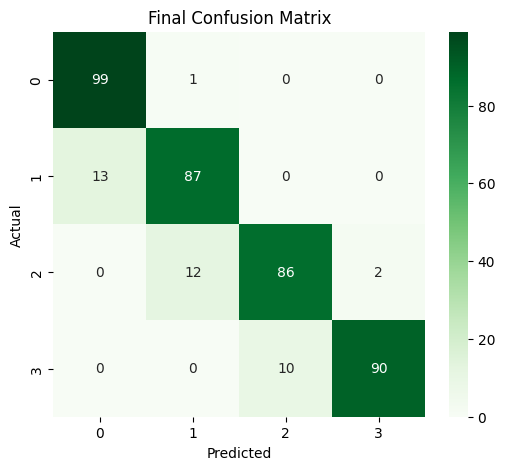

In [279]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Greens",
    fmt='d'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Final Confusion Matrix")

plt.show()

In [280]:
print("""
Conclusion

1. Built an Artificial Neural Network classifier.

2. StandardScaler was used for feature scaling.

3. Hyperparameter tuning was performed using Keras Tuner.

4. The tuned model achieved improved classification performance.

5. The ANN successfully classified mobile price ranges.
""")


Conclusion

1. Built an Artificial Neural Network classifier.

2. StandardScaler was used for feature scaling.

3. Hyperparameter tuning was performed using Keras Tuner.

4. The tuned model achieved improved classification performance.

5. The ANN successfully classified mobile price ranges.

